# ANALISIS DE PARETO Y CLASIFICACION ABC

**Autor: Abdias Figueredo V.**

**Version: 1.0**

**Agosto 2025**

**Cochabamba, Bolivia**

## Índice
1.  **Introducción**

2.  **Configuración Inicial**

3.  **Analisis Univariado**

4.  **Análisis de Distribuciones**

5.  **Análisis de Outliers**

7.  **Conclusiones**

## 1. INTRODUCCIÓN

Este proyecto tiene como objetivo realizar un Análisis Exploratorio de Datos (EDA) exhaustivo de los datos de ventas, productos e inventario de una empresa importadora de autopartes. La empresa maneja alrededor de 10,000 SKUs diferentes y tiene registros desde 2018 hasta la fecha actual, generados con IA simulando un sistema SAP Business One.

**Objetivos del EDA:**

*   Comprender la estructura y calidad de los datos disponibles.
*   Identificar patrones y tendencias en las ventas a lo largo del tiempo.
*   Analizar el comportamiento de los diferentes SKUs en términos de ventas y rotación de inventario.
*   Detectar posibles problemas en los datos, como valores atípicos o inconsistencias.
*   Generar hipótesis para futuros análisis y modelado predictivo.

**Tablas de Datos:**

*   **OITM (Tabla de Productos):** Contiene información detallada sobre cada producto, incluyendo su código, descripción, precio, etc.
*   **INV1 (Tabla de Ventas):** Registra las transacciones de venta, incluyendo la fecha, el SKU vendido, la cantidad, el precio, etc.
*   **OINM (Tabla de Inventario):** Contiene información sobre los movimientos de inventario, como entradas, salidas y ajustes.

---

## 2. CONFIGURACION INICIAL

### 2.1 Importación de librerías necesarias

In [57]:
# INSTALACION DE REQUIREMENTS
# Comando alternativo: pip install -r requirements.txt
#!pip install -r requirements.txt --quiet
# pip install --only-binary :all: statsforecast

In [58]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
# Manejo y procesamiento de datos
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import os
import scipy.stats as stats
from pandas.tseries.offsets import DateOffset

# Análisis de series temporales
# -----------------------------------------------------------------------------
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualización
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de advertencias
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilos de visualización
# =============================================================================
# Configuración general de matplotlib
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (18, 7),
    'axes.facecolor': '#FFFFFF',  # Fondo blanco para mejor legibilidad
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Configuración de seaborn
#sns.set_theme(style="whitegrid", 
#              rc={'axes.facecolor': '#FFFFFF'},
#              font_scale=1.1)

### 2.2 Carga de datos

In [59]:
# # =============================================================================
# # CARGA DE DATOS
# # =============================================================================
# # Definición de rutas de archivos
# DATA_DIR = '../data/bronze'
# FILE_PATHS = {
#     'oitm': os.path.join(DATA_DIR, 'oitm.parquet'),
#     'inv1': os.path.join(DATA_DIR, 'inv1.parquet'),
#     'oinm': os.path.join(DATA_DIR, 'oinm.parquet')
# }

# # Carga de datos con manejo de errores
# try:
#     # Cargar datos en un diccionario para mejor organización
#     data = {
#         'oitm': pd.read_parquet(FILE_PATHS['oitm']),
#         'inv1': pd.read_parquet(FILE_PATHS['inv1']),
#         'oinm': pd.read_parquet(FILE_PATHS['oinm'])
#     }
    
#     # Crear copias para procesamiento
#     df_oitm = data['oitm'].copy()
#     df_inv1 = data['inv1'].copy()
#     df_oinm = data['oinm'].copy()
    
#     # Verificación de carga exitosa
#     print("✅ Datos cargados exitosamente")
#     print(f"📊 Registros cargados:")
#     print(f"   - oitm: {len(df_oitm):,} registros")
#     print(f"   - inv1: {len(df_inv1):,} registros")
#     print(f"   - oinm: {len(df_oinm):,} registros")
#     # 
# except Exception as e:
#     print(f"❌ Error al cargar los datos: {str(e)}")
#     # Opcional: cargar datos de respaldo o finalizar la ejecución
#     raise

In [60]:
# CARGA DE DATOS INV1
dataSales = pd.read_parquet('../data/bronze/inv1.parquet')
dfSales = dataSales.copy()

In [61]:
# CARGA DE DATOS OITM
dataItems = pd.read_parquet('../data/bronze/oitm.parquet')
dfItems = dataItems.copy()

---

### 2.3 Limpieza inicial

#### 2.3.1 Filtrado de Items

In [62]:
# INNER JOIN ENTRE OINM Y OITM PARA FILTRAR ITEMS INACTIVOS Y GRUPOS
dfSales = dfSales.merge(dfItems[['ItemCode', 'ItemGrp', 'FrozenFor']], 
                        on='ItemCode', 
                        how='inner')

In [63]:
# FILTRAR PARA QUITAR ITEMS INACTIVOS Y GRUPOS
def filter_active_items(df):
    """
    Filtra el DataFrame para eliminar items inactivos y grupos.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con columnas 'FrozenFor' y 'ItemGrp'
        
    Retorna:
    --------
    pandas.DataFrame
        DataFrame filtrado sin items inactivos ni grupos
    """
    # Filtrar items activos (no congelados) y grupos (no vacíos)
    filtered_df = df[(df['FrozenFor'] == 'N') & (df['ItemGrp'] != 124)]
    
    # Verificar si se eliminaron filas
    if len(filtered_df) < len(df):
        print(f"⚠️ Se eliminaron {len(df) - len(filtered_df):,} filas de items inactivos o grupos vacíos")
    
    return filtered_df

In [64]:
# USO DE LA FUNCION
dfSales = filter_active_items(dfSales)

⚠️ Se eliminaron 76,145 filas de items inactivos o grupos vacíos


In [65]:
# MOSTRAR LOS GRUPOS UNICOS
print("📋 ItemGrp únicos:"
      , dfSales['ItemGrp'].unique())

📋 ItemGrp únicos: [708 101 202 303 405 506 809 607]


#### 2.3.2 Muestreo de ultimos 12 meses

In [66]:
# FUNCION PARA FILTRAR LOS ULTIMOS 12 MESES CERRADOS
def filter_last_12_months(df, 
                          date_col='DocDate', 
                          ref_date=None):
    """
    Filtra el DataFrame para incluir solo los registros de los últimos 12 meses cerrados.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con una columna de fechas.
    date_col : str
        Nombre de la columna de fechas en el DataFrame.
    ref_date : str o pd.Timestamp, opcional
        Fecha de referencia para calcular los últimos 12 meses. Si es None, se usa la fecha máxima en df[date_col].
        
    Retorna:
    --------
    pandas.DataFrame
        DataFrame filtrado con registros de los últimos 12 meses cerrados.
    """
    # Convertir la columna de fechas a datetime si no lo está
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Determinar la fecha de referencia
    if ref_date is None:
        ref_date = df[date_col].max()
    else:
        ref_date = pd.to_datetime(ref_date)
    
    # Calcular la fecha límite (hace 12 meses desde el inicio del mes de ref_date)
    start_of_ref_month = ref_date.replace(day=1)
    start_of_12_months_ago = start_of_ref_month - DateOffset(months=12)
    
    # Filtrar el DataFrame
    filtered_df = df[df[date_col] < start_of_ref_month]
    filtered_df = filtered_df[filtered_df[date_col] >= start_of_12_months_ago]
    
    print(f"📅 Filtrado a los últimos 12 meses cerrados: {start_of_12_months_ago.date()} a {start_of_ref_month.date() - pd.Timedelta(days=1)}")
    
    return filtered_df

In [67]:
# USO DE LA FUNCION
dfSales = filter_last_12_months(dfSales, date_col='DocDate')

📅 Filtrado a los últimos 12 meses cerrados: 2024-08-01 a 2025-07-31


## 3. ANALISIS DE PARETO

In [68]:
# FUNCION PARA ELABORAR DATAFRAME DE PARETO
def create_pareto_df(df, 
                     group_col='ItemCode', 
                     value_col='LineTotal', 
                     date_col='DocDate'):
    """
    Crea un DataFrame de Pareto con los items más vendidos.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con las columnas especificadas.
    group_col : str
        Columna por la cual agrupar (default: 'ItemCode').
    value_col : str
        Columna con los valores a sumar (default: 'LineTotal').
    date_col : str
        Columna de fechas para filtrar (default: 'DocDate').
        
    Retorna:
    --------
    pandas.DataFrame
        DataFrame ordenado por cantidad vendida y porcentaje acumulado.
    """
    # Agrupar por item y sumar las cantidades vendidas
    pareto_df = df.groupby(group_col)[value_col].sum().round(2).reset_index()
    
    # Ordenar por cantidad vendida en orden descendente
    pareto_df = pareto_df.sort_values(by=value_col, ascending=False)
    
    # Calcular el porcentaje
    total_sales = pareto_df[value_col].sum()
    pareto_df['Percentage'] = ((pareto_df[value_col] / total_sales) * 100).round(2)

    # Calcular el porcentaje acumulado
    pareto_df['CumulativePercentage'] = ((pareto_df[value_col].cumsum() / total_sales) * 100).round(2)
    
    return pareto_df.reset_index(drop=True)

In [69]:
# USO DE LA FUNCION
dfPareto = create_pareto_df(dfSales, 
                            group_col='ItemCode',
                            value_col='LineTotal',
                            date_col='DocDate')

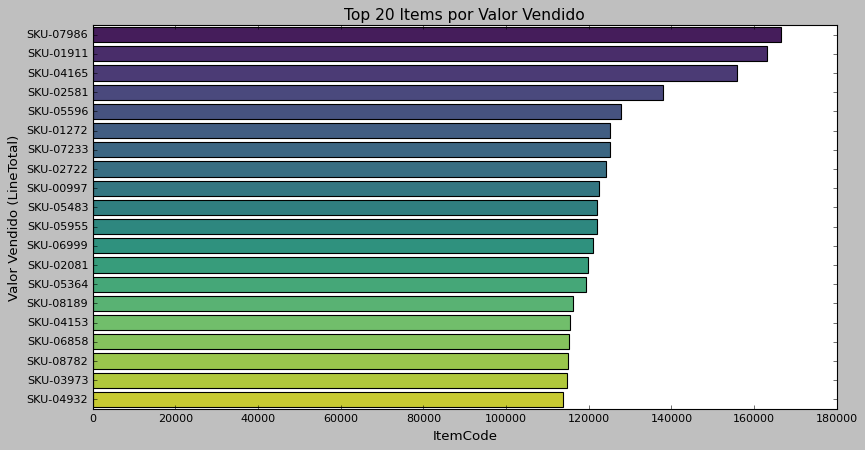

In [70]:
# GRAFICO DE TOP ITEMS POR VALOR VENDIDO
top_n = 20
plt.figure(figsize=(12, 6))
sns.barplot(data=dfPareto.head(top_n),
            x='LineTotal', 
            y='ItemCode', 
            palette='viridis')
plt.title(f'Top {top_n} Items por Valor Vendido')
plt.xlabel('ItemCode')
plt.ylabel('Valor Vendido (LineTotal)')
plt.show()


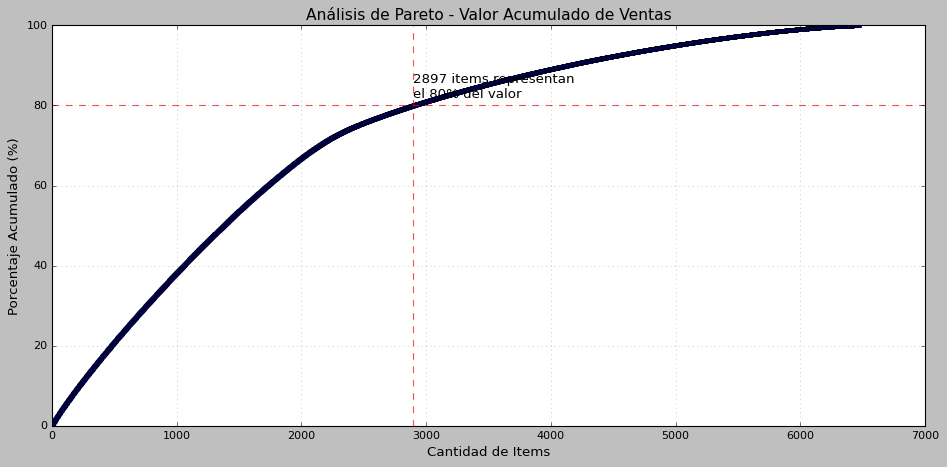


Resultados del análisis:
- Total de items: 6,473
- Items que representan el 80% del valor: 2,897 (44.8% del total)


In [71]:
# GRAFICO DE PARETO 

plt.figure(figsize=(12, 6))

# Graficar la línea del porcentaje acumulado
plt.plot(dfPareto.index, 
         dfPareto['CumulativePercentage'], 
         color='blue', 
         linewidth=2,
         marker='o',
         markersize=4)

# Añadir línea horizontal en 80%
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% del valor')

# Encontrar el punto donde se cruza el 80%
items_80 = dfPareto[dfPareto['CumulativePercentage'] <= 80].shape[0]
plt.axvline(x=items_80, color='red', linestyle='--', alpha=0.7)

# Configurar etiquetas y título
plt.xlabel('Cantidad de Items')
plt.ylabel('Porcentaje Acumulado (%)')
plt.title('Análisis de Pareto - Valor Acumulado de Ventas')

# Añadir texto informativo
plt.text(items_80 + 0.5, 82, 
         f'{items_80} items representan\nel 80% del valor', 
         horizontalalignment='left')

# Ajustar el diseño
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Mostrar información numérica
print(f"\nResultados del análisis:")
print(f"- Total de items: {len(dfPareto):,}")
print(f"- Items que representan el 80% del valor: {items_80:,} ({(items_80/len(dfPareto)*100):.1f}% del total)")

## 4. CLASIFICACION ABC

In [72]:
# FUNCION PARA CLASIFICAR ITEMS EN ABC SEGUN PARETO
def classify_abc(df, 
                 value_col='LineTotal', 
                 cumulative_col='CumulativePercentage'):
    """
    Clasifica los items en categorías A, B y C según el análisis de Pareto.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con las columnas 'CumulativePercentage' y 'value_col'.
    value_col : str
        Columna con los valores a clasificar (default: 'LineTotal').
    cumulative_col : str
        Columna con el porcentaje acumulado (default: 'CumulativePercentage').
        
    Retorna:
    --------
    pandas.DataFrame
        DataFrame con una nueva columna 'ABC' que indica la clasificación.
    """
    # Clasificación ABC
    conditions = [
        (df[cumulative_col] <= 50),
        (df[cumulative_col] > 50) & (df[cumulative_col] <= 85),
        (df[cumulative_col] > 85)
    ]
    choices = ['A', 'B', 'C']
    
    df['ABC'] = np.select(conditions, choices, default='C')
    
    return df.reset_index(drop=True)

In [73]:
# USO DE LA FUNCION
dfABC = classify_abc(dfPareto, 
                     value_col='LineTotal',
                    cumulative_col='CumulativePercentage')

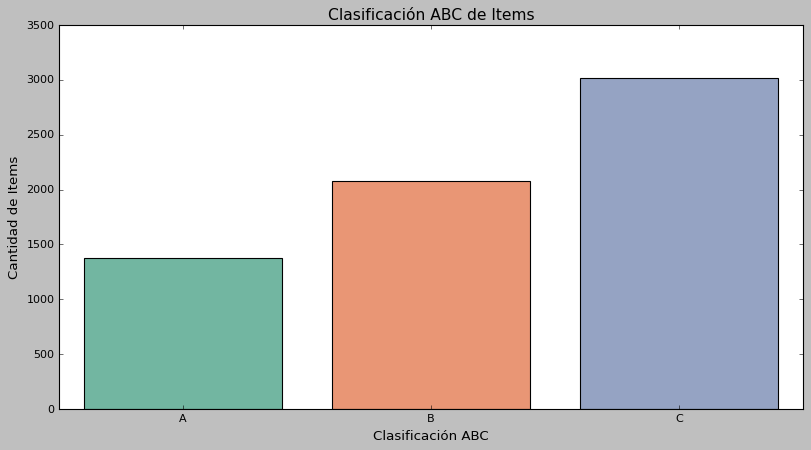

In [75]:
# GRAFICO DE CLASIFICACION ABC
plt.figure(figsize=(12, 6))
sns.countplot(data=dfABC, 
              x='ABC', 
              order=['A', 'B', 'C'], 
              palette='Set2')
plt.title('Clasificación ABC de Items')
plt.xlabel('Clasificación ABC')
plt.ylabel('Cantidad de Items')
plt.show()


## 6. GUARDADO DE DATAFRAME

In [74]:
# GUARDAR EL DATAFRAME PROCESADO DFStock
dfABC.to_parquet('../data/silver/dfABC.parquet', index=False)

## 6. CONCLUSIONES

- Se identificaron que los productos mas vendidos son los SKUs 06074, 03543 y 03063.
- El análisis de distribución mostró que las ventas semanales no siguen una distribución normal (p-valor < 0.05 en la prueba de Shapiro-Wilk), lo que es común en datos de ventas del mundo real debido a factores externos como promociones o eventos estacionales.
- El analisis de outliers mostro que hay 2 valoes atipicos en la variable ventas semanales. Es coveniente normalizar estos datos ya que el proximo paso sera crear un modelo de pronostico.